# MAIAC AOD 550nm (MCD19A2) — Google Earth Engine

**Product:** MODIS/061/MCD19A2_GRANULES
**Band:** `Optical_Depth_055` — AOD tại 550nm (scale ×0.001)
**Resolution:** 1km, daily (Terra + Aqua combined)
**Method:** GEE Python API — extract point values tại 6 trạm Hà Nội

**Setup một lần:**
1. Có tài khoản Google — đăng ký GEE miễn phí: https://earthengine.google.com/
2. `pip install earthengine-api`
3. Chạy `earthengine authenticate` trong terminal (một lần duy nhất)

## Cell 1 — Cài đặt

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'earthengine-api'])
print('earthengine-api ready.')

earthengine-api ready.


## Cell 2 — Authenticate GEE (chạy 1 lần)

Nếu chưa authenticate, chạy trong terminal:
```
earthengine authenticate
```
Hoặc dùng service account — cell dưới dùng `ee.Authenticate()` tự động mở browser.

In [2]:
import ee

# Neu chua biet project ID, de GEE_PROJECT = None
# Tim project ID tai: https://console.cloud.google.com/ (Project selector o goc tren)
GEE_PROJECT = "silken-gadget-419107"   # vi du: "my-gee-project-123" hoac de None

try:
    if GEE_PROJECT:
        ee.Initialize(project=GEE_PROJECT)
    else:
        ee.Initialize()  # dung default credentials
    print("GEE initialized OK.")
except ee.EEException:
    print("Credentials chua co. Chay earthengine authenticate trong terminal truoc.")
    ee.Authenticate()
    if GEE_PROJECT:
        ee.Initialize(project=GEE_PROJECT)
    else:
        ee.Initialize()
    print("GEE initialized OK (after auth).")


# Kiem tra collection ton tai
n = ee.ImageCollection("MODIS/061/MCD19A2_GRANULES").filterDate("2024-01-01","2024-01-02").size().getInfo()
print(f"MCD19A2 granules on 2024-01-01: {n}  -> collection OK")

GEE initialized OK.


MCD19A2 granules on 2024-01-01: 1297  -> collection OK


## Cell 3 — Cấu hình

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import time

ROOT     = Path('D:/Bussiness_plan/Multimodal_PM25')
RAW_DIR  = ROOT / 'data/raw/maiac';  RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR = ROOT / 'data/processed';  PROC_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV  = PROC_DIR / 'maiac_aod_daily.csv'
MERGED   = PROC_DIR / 'daily_merged.csv'

STATIONS = {
    2161292: (21.0152, 105.7999),
    2161306: (21.0500, 105.7400),
    4946811: (21.0491, 105.8831),
    4946812: (21.0031, 105.7947),
    4946813: (21.0052, 105.8418),
    6123215: (20.9933, 105.9441),
}

DATE_START = '2024-01-01'
DATE_END   = '2026-05-15'

# MCD19A2 bands + scales
COLLECTION  = 'MODIS/061/MCD19A2_GRANULES'
AOD_BAND    = 'Optical_Depth_055'   # AOD 550nm, scale ×0.001
AOD_BAND_047 = 'Optical_Depth_047'  # AOD 470nm, scale ×0.001
FMF_BAND    = 'FineModeFraction'    # Fine mode fraction 0–1, scale ×0.01
AOD_SCALE   = 0.001
FMF_SCALE   = 0.01
QA_BAND     = 'AOD_QA'
BUFFER_M    = 5000

# All feature columns produced by extraction (for consistency checks)
FEATURE_COLS = [
    'aod_mean', 'aod_median', 'aod_max', 'aod_std', 'aod_count',
    'aod047_mean', 'aod047_median',
    'fmf_mean', 'fmf_median',
]

print(f'Stations  : {len(STATIONS)}')
print(f'Period    : {DATE_START} -> {DATE_END}')
print(f'Output    : {OUT_CSV}')
print(f'Bands     : {AOD_BAND}, {AOD_BAND_047}, {FMF_BAND}')


Stations  : 6
Period    : 2024-01-01 -> 2026-05-15
Output    : D:\Bussiness_plan\Multimodal_PM25\data\processed\maiac_aod_daily.csv
Bands     : Optical_Depth_055, Optical_Depth_047, FineModeFraction


## Cell 4 — Hàm extract AOD từ GEE

In [4]:
from datetime import datetime, timedelta

def next_day(date_str):
    return (datetime.strptime(date_str, "%Y-%m-%d") + timedelta(days=1)).strftime("%Y-%m-%d")


# MODIS tiles covering Hanoi (~21N, 105-106E)
HANOI_TILE_FILTER = ee.Filter.Or(
    ee.Filter.stringContains("system:index", "h27v06"),
    ee.Filter.stringContains("system:index", "h28v06"),
)

_STAT_REDUCER = (ee.Reducer.mean()
                 .combine(ee.Reducer.median(), sharedInputs=True)
                 .combine(ee.Reducer.max(),    sharedInputs=True)
                 .combine(ee.Reducer.stdDev(), sharedInputs=True)
                 .combine(ee.Reducer.count(),  sharedInputs=True))

_EMPTY_ROW = {
    'aod_mean': None, 'aod_median': None, 'aod_max': None,
    'aod_std': None, 'aod_count': 0,
    'aod047_mean': None, 'aod047_median': None,
    'fmf_mean': None,   'fmf_median': None,
}


def extract_aod_station(loc_id, lat, lon, date_str):
    """
    Extract MAIAC AOD 550nm, 470nm and FineModeFraction at one station for one day.
    Each band gets its own scale factor before reduceRegion so all stats are physical units.
    Returns None fields for cloudy days (count=0) — gap-filled later.
    """
    region = ee.Geometry.Point([lon, lat]).buffer(BUFFER_M)

    col = (ee.ImageCollection(COLLECTION)
           .filterDate(date_str, next_day(date_str))
           .filter(HANOI_TILE_FILTER)
           .select([AOD_BAND, AOD_BAND_047, FMF_BAND]))

    if col.size().getInfo() == 0:
        return dict(_EMPTY_ROW)

    # Scale each band separately so stats are in physical units
    img = (col.select([AOD_BAND]).mean().multiply(AOD_SCALE).rename('aod055')
             .addBands(col.select([AOD_BAND_047]).mean().multiply(AOD_SCALE).rename('aod047'))
             .addBands(col.select([FMF_BAND]).mean().multiply(FMF_SCALE).rename('fmf')))

    s = img.reduceRegion(
        reducer=_STAT_REDUCER,
        geometry=region,
        scale=1000,
        maxPixels=1e6,
    ).getInfo()

    return {
        'aod_mean':    s.get('aod055_mean'),
        'aod_median':  s.get('aod055_median'),
        'aod_max':     s.get('aod055_max'),
        'aod_std':     s.get('aod055_stdDev'),
        'aod_count':   s.get('aod055_count'),
        'aod047_mean':  s.get('aod047_mean'),
        'aod047_median': s.get('aod047_median'),
        'fmf_mean':    s.get('fmf_mean'),
        'fmf_median':  s.get('fmf_median'),
    }


# Quick test — dry season day with likely clear sky
test = extract_aod_station(2161292, 21.0152, 105.7999, '2024-11-15')
print('Test result:', test)


Test result: {'aod_mean': 0.6464580806549421, 'aod_median': 0.654, 'aod_max': 0.753, 'aod_std': 0.0593151247462953, 'aod_count': 65, 'aod047_mean': 0.8422353699211644, 'aod047_median': 0.851, 'fmf_mean': 0.05, 'fmf_median': 0.05}


In [5]:
# ── Diagnostic v3: tim ngay co du lieu ──────────────────────────────────────
vietnam = ee.Geometry.Rectangle([102.0, 8.0, 110.0, 24.0])  # toan Viet Nam
hanoi   = ee.Geometry.Rectangle([105.5, 20.8, 106.1, 21.2])

tile_filter = ee.Filter.Or(
    ee.Filter.stringContains("system:index", "h27v06"),
    ee.Filter.stringContains("system:index", "h28v06"),
)

test_dates = [
    ("2024-03-15", "2024-03-16"),   # cuoi mua dong
    ("2024-05-01", "2024-05-02"),   # mua he bat dau
    ("2024-10-20", "2024-10-21"),   # mua kho, troi quang
    ("2024-11-15", "2024-11-16"),   # o nhiem cao nhat
    ("2024-12-01", "2024-12-02"),
]

for s, e in test_dates:
    col = (ee.ImageCollection(COLLECTION)
           .filterDate(s, e)
           .filter(tile_filter)
           .select([AOD_BAND]))
    # No mask — raw mean
    raw = col.mean().reduceRegion(
        reducer=ee.Reducer.count().combine(ee.Reducer.mean(), sharedInputs=True),
        geometry=hanoi, scale=1000, maxPixels=1e7
    ).getInfo()
    cnt  = raw.get("Optical_Depth_055_count", 0)
    mean = raw.get("Optical_Depth_055_mean")
    aod  = round(mean * AOD_SCALE, 3) if mean else None
    print(f"{s}: count={cnt}  raw_mean={mean}  AOD={aod}")

2024-03-15: count=0  raw_mean=None  AOD=None


2024-05-01: count=0  raw_mean=None  AOD=None


2024-10-20: count=9  raw_mean=414.21229293809944  AOD=0.414


2024-11-15: count=1682  raw_mean=529.6627955441044  AOD=0.53


2024-12-01: count=2367  raw_mean=444.12595392960293  AOD=0.444


## Cell 5 — Tạo danh sách ngày từ daily_merged.csv

In [6]:
main      = pd.read_csv(MERGED, parse_dates=['date'])
dates_all = sorted(main['date'].dt.strftime('%Y-%m-%d').unique())
print(f'Total dates  : {len(dates_all)}  ({dates_all[0]} -> {dates_all[-1]})')
print(f'Total requests: {len(STATIONS)} x {len(dates_all)} = {len(STATIONS)*len(dates_all):,}')

Total dates  : 830  (2024-02-06 -> 2026-05-15)
Total requests: 6 x 830 = 4,980


## Cell 6 — Crawl AOD (có checkpoint, resume nếu bị ngắt)

> ~2–4 requests/giây với GEE free tier. 6 trạm × 870 ngày ≈ 5200 requests → **~30–60 phút**.

In [7]:
NEW_COLS = {'aod047_mean', 'aod047_median', 'fmf_mean', 'fmf_median'}

def _fallback(loc_id, date_str):
    return {'location_id': loc_id, 'date': date_str,
            'aod_mean': None, 'aod_median': None, 'aod_max': None,
            'aod_std': None, 'aod_count': None,
            'aod047_mean': None, 'aod047_median': None,
            'fmf_mean': None, 'fmf_median': None}

all_dfs = []

for loc_id, (lat, lon) in STATIONS.items():
    cache_file = RAW_DIR / f'maiac_{loc_id}.csv'

    if cache_file.exists() and cache_file.stat().st_size > 100:
        df_st = pd.read_csv(cache_file)
        missing_new = NEW_COLS - set(df_st.columns)
        if missing_new:
            # Cache lacks new bands — must re-crawl all dates
            print(f'Station {loc_id}: cache missing {missing_new} → re-crawling all dates')
            df_st     = pd.DataFrame()
            remaining = dates_all
        else:
            done      = set(df_st['date'].tolist())
            remaining = [d for d in dates_all if d not in done]
            print(f'Station {loc_id}: {len(done)} cached, {len(remaining)} remaining')
    else:
        df_st     = pd.DataFrame()
        remaining = dates_all
        print(f'Station {loc_id}: starting fresh ({len(remaining)} dates)')

    rows = []
    for i, date_str in enumerate(remaining):
        for attempt in range(3):
            try:
                feat = extract_aod_station(loc_id, lat, lon, date_str)
                feat['location_id'] = loc_id
                feat['date']        = date_str
                rows.append(feat)
                break
            except Exception as e:
                if attempt == 2:
                    print(f'  SKIP {date_str}: {e}')
                    rows.append(_fallback(loc_id, date_str))
                else:
                    time.sleep(5)

        if (i + 1) % 50 == 0 or (i + 1) == len(remaining):
            df_new = pd.DataFrame(rows)
            df_st  = pd.concat([df_st, df_new], ignore_index=True)
            df_st.to_csv(cache_file, index=False)
            rows = []
            pct  = df_st['aod_mean'].notna().mean() * 100
            print(f'  [{loc_id}] {i+1}/{len(remaining)} done | coverage {pct:.0f}%')

    all_dfs.append(df_st)
    print(f'  Station {loc_id} complete: {len(df_st)} rows')

aod_df = (pd.concat(all_dfs, ignore_index=True)
          .sort_values(['location_id', 'date'])
          .reset_index(drop=True))

print(f'\nTotal rows : {len(aod_df)}')
print(f'Coverage aod_mean  : {aod_df["aod_mean"].notna().mean()*100:.1f}%')
print(f'Coverage aod047    : {aod_df["aod047_mean"].notna().mean()*100:.1f}%')
print(f'Coverage fmf_mean  : {aod_df["fmf_mean"].notna().mean()*100:.1f}%')
print(aod_df[['aod_mean', 'aod047_mean', 'fmf_mean', 'aod_count']].describe().round(3))


Station 2161292: cache missing {'fmf_mean', 'fmf_median', 'aod047_mean', 'aod047_median'} → re-crawling all dates


  [2161292] 50/830 done | coverage 12%


  [2161292] 100/830 done | coverage 17%


  [2161292] 150/830 done | coverage 13%


  [2161292] 200/830 done | coverage 12%


...

  [6123215] 650/830 done | coverage 27%


  [6123215] 700/830 done | coverage 28%


  [6123215] 750/830 done | coverage 27%


  [6123215] 800/830 done | coverage 27%


  [6123215] 830/830 done | coverage 27%
  Station 6123215 complete: 830 rows

Total rows : 4980
Coverage aod_mean  : 25.2%
Coverage aod047    : 25.2%
Coverage fmf_mean  : 100.0%
       aod_mean  aod047_mean  fmf_mean  aod_count
count  1256.000     1256.000   4980.00   4980.000
mean      0.545        0.710      0.05     14.520
std       0.394        0.505      0.00     32.471
min       0.036        0.048      0.05      0.000
25%       0.284        0.376      0.05      0.000
50%       0.412        0.543      0.05      0.000
75%       0.718        0.933      0.05      1.000
max       2.938        3.781      0.05    106.000


## Cell 7 — Gap-fill (mây che phủ)

In [8]:
AOD_FILL_COLS = ["aod_mean", "aod_median", "aod047_mean", "aod047_median", "fmf_mean", "fmf_median"]

filled = []
for loc_id, grp in aod_df.groupby("location_id"):
    g = grp.set_index("date").sort_index()
    g = g.drop(columns=["location_id"], errors="ignore")
    g.index = pd.to_datetime(g.index)

    # Step 1: linear interpolation across cloud gaps ≤ 5 days
    for col in AOD_FILL_COLS:
        if col in g.columns:
            g[col] = g[col].interpolate(method="linear", limit=5, limit_direction="both")

    # Step 2: monthly median fallback for longer gaps
    g["_month"] = g.index.month
    for col in AOD_FILL_COLS:
        if col in g.columns:
            monthly_med = g.groupby("_month")[col].transform("median")
            g[col] = g[col].fillna(monthly_med).fillna(g[col].median())

    g = g.drop(columns=["_month"])
    g = g.reset_index().rename(columns={"index": "date"})
    g["location_id"] = loc_id
    filled.append(g)

aod_filled = pd.concat(filled, ignore_index=True)
print(f"Coverage after gap-fill:")
for col in AOD_FILL_COLS:
    if col in aod_filled.columns:
        pct = aod_filled[col].notna().mean() * 100
        print(f"  {col}: {pct:.1f}%")
print(aod_filled[["aod_mean", "aod047_mean", "fmf_mean"]].describe().round(3))


Coverage after gap-fill:
  aod_mean: 100.0%
  aod_median: 100.0%
  aod047_mean: 100.0%
  aod047_median: 100.0%
  fmf_mean: 100.0%
  fmf_median: 100.0%
       aod_mean  aod047_mean  fmf_mean
count  4980.000     4980.000   4980.00
mean      0.509        0.664      0.05
std       0.316        0.405      0.00
min       0.036        0.048      0.05
25%       0.311        0.411      0.05
50%       0.400        0.526      0.05
75%       0.624        0.813      0.05
max       2.938        3.781      0.05


## Cell 8 — Lưu maiac_aod_daily.csv

In [9]:
aod_filled.to_csv(OUT_CSV, index=False)
print(f'Saved : {OUT_CSV}')
print(f'Shape : {aod_filled.shape}')

Saved : D:\Bussiness_plan\Multimodal_PM25\data\processed\maiac_aod_daily.csv
Shape : (4980, 11)


## Cell 9 — Visualize

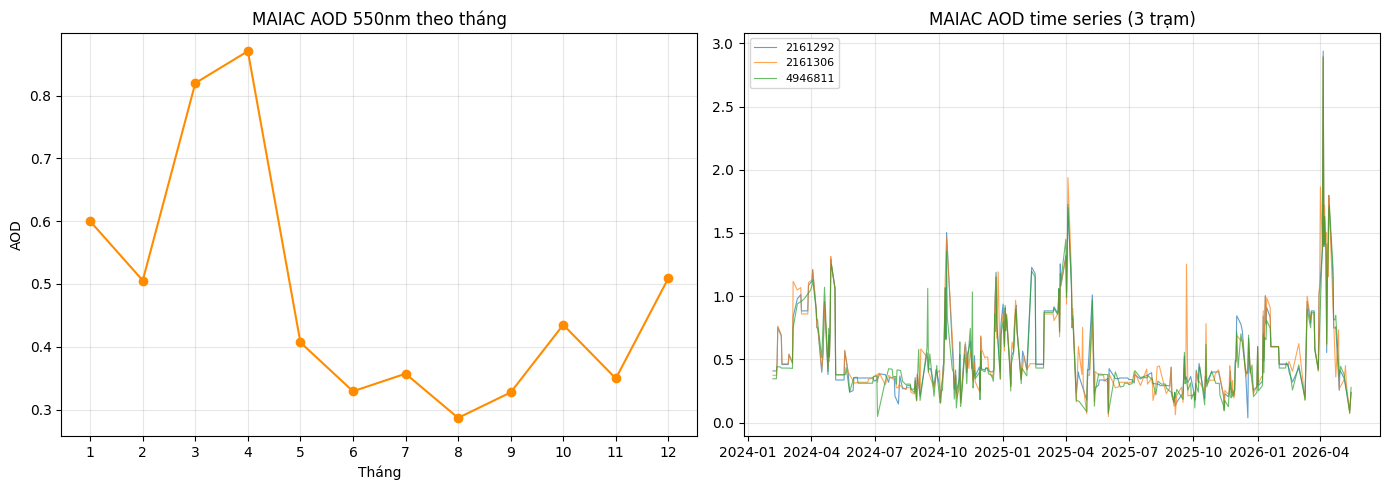

In [10]:
import matplotlib.pyplot as plt

aod_filled['date']  = pd.to_datetime(aod_filled['date'])
aod_filled['month'] = aod_filled['date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

aod_filled.groupby('month')['aod_mean'].mean().plot(
    ax=axes[0], marker='o', color='darkorange')
axes[0].set_title('MAIAC AOD 550nm theo tháng'); axes[0].set_xticks(range(1,13))
axes[0].set_xlabel('Tháng'); axes[0].set_ylabel('AOD'); axes[0].grid(alpha=0.3)

for loc_id, (lat, lon) in list(STATIONS.items())[:3]:
    sub = aod_filled[aod_filled['location_id'] == loc_id]
    axes[1].plot(sub['date'], sub['aod_mean'], alpha=0.7, linewidth=0.8, label=str(loc_id))
axes[1].set_title('MAIAC AOD time series (3 trạm)')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'outputs/maiac_aod_seasonal.png', dpi=120, bbox_inches='tight')
plt.show()

## Cell 10 — Correlation AOD vs PM2.5

Pearson r (AOD vs PM2.5): 0.187  (n=2566)


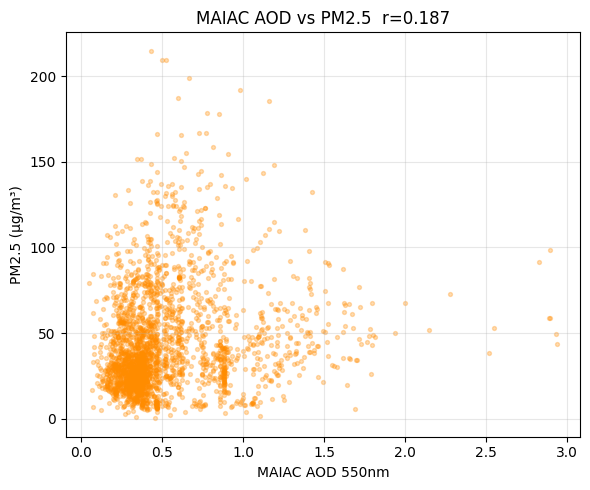

In [11]:
import matplotlib.pyplot as plt

main = pd.read_csv(MERGED, parse_dates=['date'])
aod_filled['date'] = pd.to_datetime(aod_filled['date'])

check = main.merge(aod_filled[['location_id','date','aod_mean']],
                   on=['location_id','date'], how='left')
valid = check[['pm25','aod_mean']].dropna()
r = valid.corr().iloc[0, 1]
print(f'Pearson r (AOD vs PM2.5): {r:.3f}  (n={len(valid)})')

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(valid['aod_mean'], valid['pm25'], alpha=0.3, s=8, color='darkorange')
ax.set_xlabel('MAIAC AOD 550nm'); ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title(f'MAIAC AOD vs PM2.5  r={r:.3f}', fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / 'outputs/maiac_aod_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

## Cell 11 — Merge vào daily_merged.csv

In [12]:
main = pd.read_csv(MERGED, parse_dates=['date'])
print(f'Before: {main.shape}')

# Drop all existing MAIAC / raw-AOD columns to avoid duplicates on re-run
drop_cols = [
    'aod_mean', 'aod_median', 'aod_min', 'aod_max', 'aod_std', 'aod_count',
    'maiac_aod_mean', 'maiac_aod_median', 'maiac_aod_max', 'maiac_aod_count',
    'aod047_mean', 'aod047_median',
    'fmf_mean', 'fmf_median',
    'angstrom_exp',
]
main.drop(columns=[c for c in drop_cols if c in main.columns], inplace=True)

# ── Compute Ångström Exponent (550/470nm) ────────────────────────────────────
# α = -ln(AOD550/AOD470) / ln(550/470)  — positive for fine (urban/smoke), ~0 for coarse (dust)
LOG_RATIO = np.log(550 / 470)
mask = (aod_filled['aod_mean'] > 0.01) & (aod_filled['aod047_mean'] > 0.01)
aod_filled['angstrom_exp'] = np.nan
aod_filled.loc[mask, 'angstrom_exp'] = (
    np.log(aod_filled.loc[mask, 'aod_mean'] / aod_filled.loc[mask, 'aod047_mean']) / LOG_RATIO
).clip(-0.1, 2.5)

# ── Merge into daily_merged ──────────────────────────────────────────────────
aod_filled['date'] = pd.to_datetime(aod_filled['date'])

# Rename to maiac_aod_* for consistency with train_3d_v2 feature names
rename_map = {
    'aod_mean':   'maiac_aod_mean',
    'aod_median': 'maiac_aod_median',
    'aod_max':    'maiac_aod_max',
    'aod_count':  'maiac_aod_count',
}
aod_merge = aod_filled.rename(columns=rename_map)

merge_cols = ['location_id', 'date',
              'maiac_aod_mean', 'maiac_aod_median', 'maiac_aod_max', 'maiac_aod_count',
              'aod047_mean', 'aod047_median',
              'fmf_mean', 'fmf_median',
              'angstrom_exp']
merge_cols = [c for c in merge_cols if c in aod_merge.columns]

main = main.merge(aod_merge[merge_cols], on=['location_id', 'date'], how='left')

for col in merge_cols[2:]:
    pct = main[col].notna().mean() * 100
    print(f'  {col}: {pct:.1f}%')

main.to_csv(MERGED, index=False)
print(f'Updated: {MERGED}  shape={main.shape}')


Before: (2566, 101)
  maiac_aod_mean: 100.0%
  maiac_aod_median: 100.0%
  maiac_aod_max: 25.1%
  maiac_aod_count: 100.0%
  aod047_mean: 100.0%
  aod047_median: 100.0%
  fmf_mean: 100.0%
  fmf_median: 100.0%
  angstrom_exp: 100.0%


Updated: D:\Bussiness_plan\Multimodal_PM25\data\processed\daily_merged.csv  shape=(2566, 107)


## Cell 12 — Thêm vào train_3d_v2.py

```python
# ctx_feats — thêm:
+ ['aod_mean', 'aod_median']

# tab_cols — thêm:
+ ['aod_mean', 'aod_median', 'aod_max', 'aod_count']
```

Xóa cache trước khi train lại:
```python
import shutil
shutil.rmtree('outputs/final_3d_v2/cache', ignore_errors=True)
```